In [1]:
import networkx as nx
import random
import numpy as np
import itertools
import re
from collections import Counter
import seaborn as sns
import pandas as pd
import pickle 
import matplotlib.pyplot as plt
from itertools import permutations

In [2]:
stage_labels = ['L1-0', 'L1-5', 'L1-8', 'L1-16', 'L2', 'L3', 'Ad-45-1', 'Ad-45-2']

In [3]:
stage_labels_plot = ['L1$_{0h}$', 'L1$_{5h}$', 'L1$_{8h}$', 'L1$_{16h}$', 'L2', 'L3', 'Ad$^{1}$', 'Ad$^{2}$']

In [4]:
# It tells Matplotlib's mathtext engine to render math upright (roman) instead of the default italics — 
# without needing to wrap your labels in \mathrm{} or edit the list.
plt.rcParams['mathtext.default'] = 'regular' 

In [5]:
with open(r'data/processed/all_c_elegans_weighted_graphs.pkl', 'rb') as file:
    all_c_elegans_weighted_graphs = pickle.load(file)

In [6]:
with open(r'data/processed/C_elegans_kin_k_cores_across_stages.pkl', 'rb') as file:
    kin_k_cores_across_stages = pickle.load(file)
    
with open(r'data/processed/C_elegans_kout_k_cores_across_stages.pkl', 'rb') as file:
    kout_k_cores_across_stages = pickle.load(file)
    
with open(r'data/processed/C_elegans_kin_s_cores_across_stages.pkl', 'rb') as file:
    kin_s_cores_across_stages = pickle.load(file)
    
with open(r'data/processed/C_elegans_kout_s_cores_across_stages.pkl', 'rb') as file:
    kout_s_cores_across_stages = pickle.load(file)

In [7]:
with open(r'data/processed/C_elegans_lineage_distance_for_witvliet_data.pkl', 'rb') as file:
    cell_lineages_distances_of_witvliet_data = pickle.load(file)

**Lineage Distance wise connection probability of k-cores**

In [8]:
connection_probability_kin_core_all_stages = {}
connection_probability_kout_core_all_stages = {}

for i, graph in enumerate(all_c_elegans_weighted_graphs):
    # Containers
    connected_pairs_per_distance_kincore = {}  # lineage dist → # connected pairs
    pair_count_per_distance_kincore = {}       # lineage dist → total pairs

    connected_pairs_per_distance_koutcore = {}  
    pair_count_per_distance_koutcore = {}   
    
    kin_core_neurons, kout_core_neurons = kin_k_cores_across_stages[i], kout_k_cores_across_stages[i]
    kin_core_subgraph, kout_core_subgraph = nx.subgraph(graph, kin_core_neurons), nx.subgraph(graph, kout_core_neurons)
    kin_core_edges, kout_core_edges = kin_core_subgraph.edges(), kout_core_subgraph.edges()

    # K-in core connection probabilities
    for source, target in permutations(kin_core_neurons, 2):  

        spclass_src, spclass_target = graph.nodes[source]['specific_class'], graph.nodes[target]['specific_class']
        
        distance = cell_lineages_distances_of_witvliet_data[(spclass_src, spclass_target)]
        pair_count_per_distance_kincore[distance] = pair_count_per_distance_kincore.get(distance, 0) + 1
        
        # Treat as directed, unweighted
        if kin_core_subgraph.has_edge(source, target):
            connected_pairs_per_distance_kincore[distance] = connected_pairs_per_distance_kincore.get(distance, 0) + 1

    # Final connection probability per lineage distance
    connection_probability_kin_core = {
        dist: connected_pairs_per_distance_kincore.get(dist, 0) / pair_count_per_distance_kincore[dist]
        for dist in pair_count_per_distance_kincore
    }

    connection_probability_kin_core_all_stages[i] = connection_probability_kin_core

    # K-out Core Connection Probabilities
    for source, target in permutations(kout_core_neurons, 2):  

        spclass_src, spclass_target = graph.nodes[source]['specific_class'], graph.nodes[target]['specific_class']
        
        distance = cell_lineages_distances_of_witvliet_data[(spclass_src, spclass_target)]
        pair_count_per_distance_koutcore[distance] = pair_count_per_distance_koutcore.get(distance, 0) + 1
        
        # Treat as directed, unweighted
        if kout_core_subgraph.has_edge(source, target):
            connected_pairs_per_distance_koutcore[distance] = connected_pairs_per_distance_koutcore.get(distance, 0) + 1

    # Final connection probability per lineage distance
    connection_probability_kout_core = {
        dist: connected_pairs_per_distance_koutcore.get(dist, 0) / pair_count_per_distance_koutcore[dist]
        for dist in pair_count_per_distance_koutcore
    }

    connection_probability_kout_core_all_stages[i] = connection_probability_kout_core


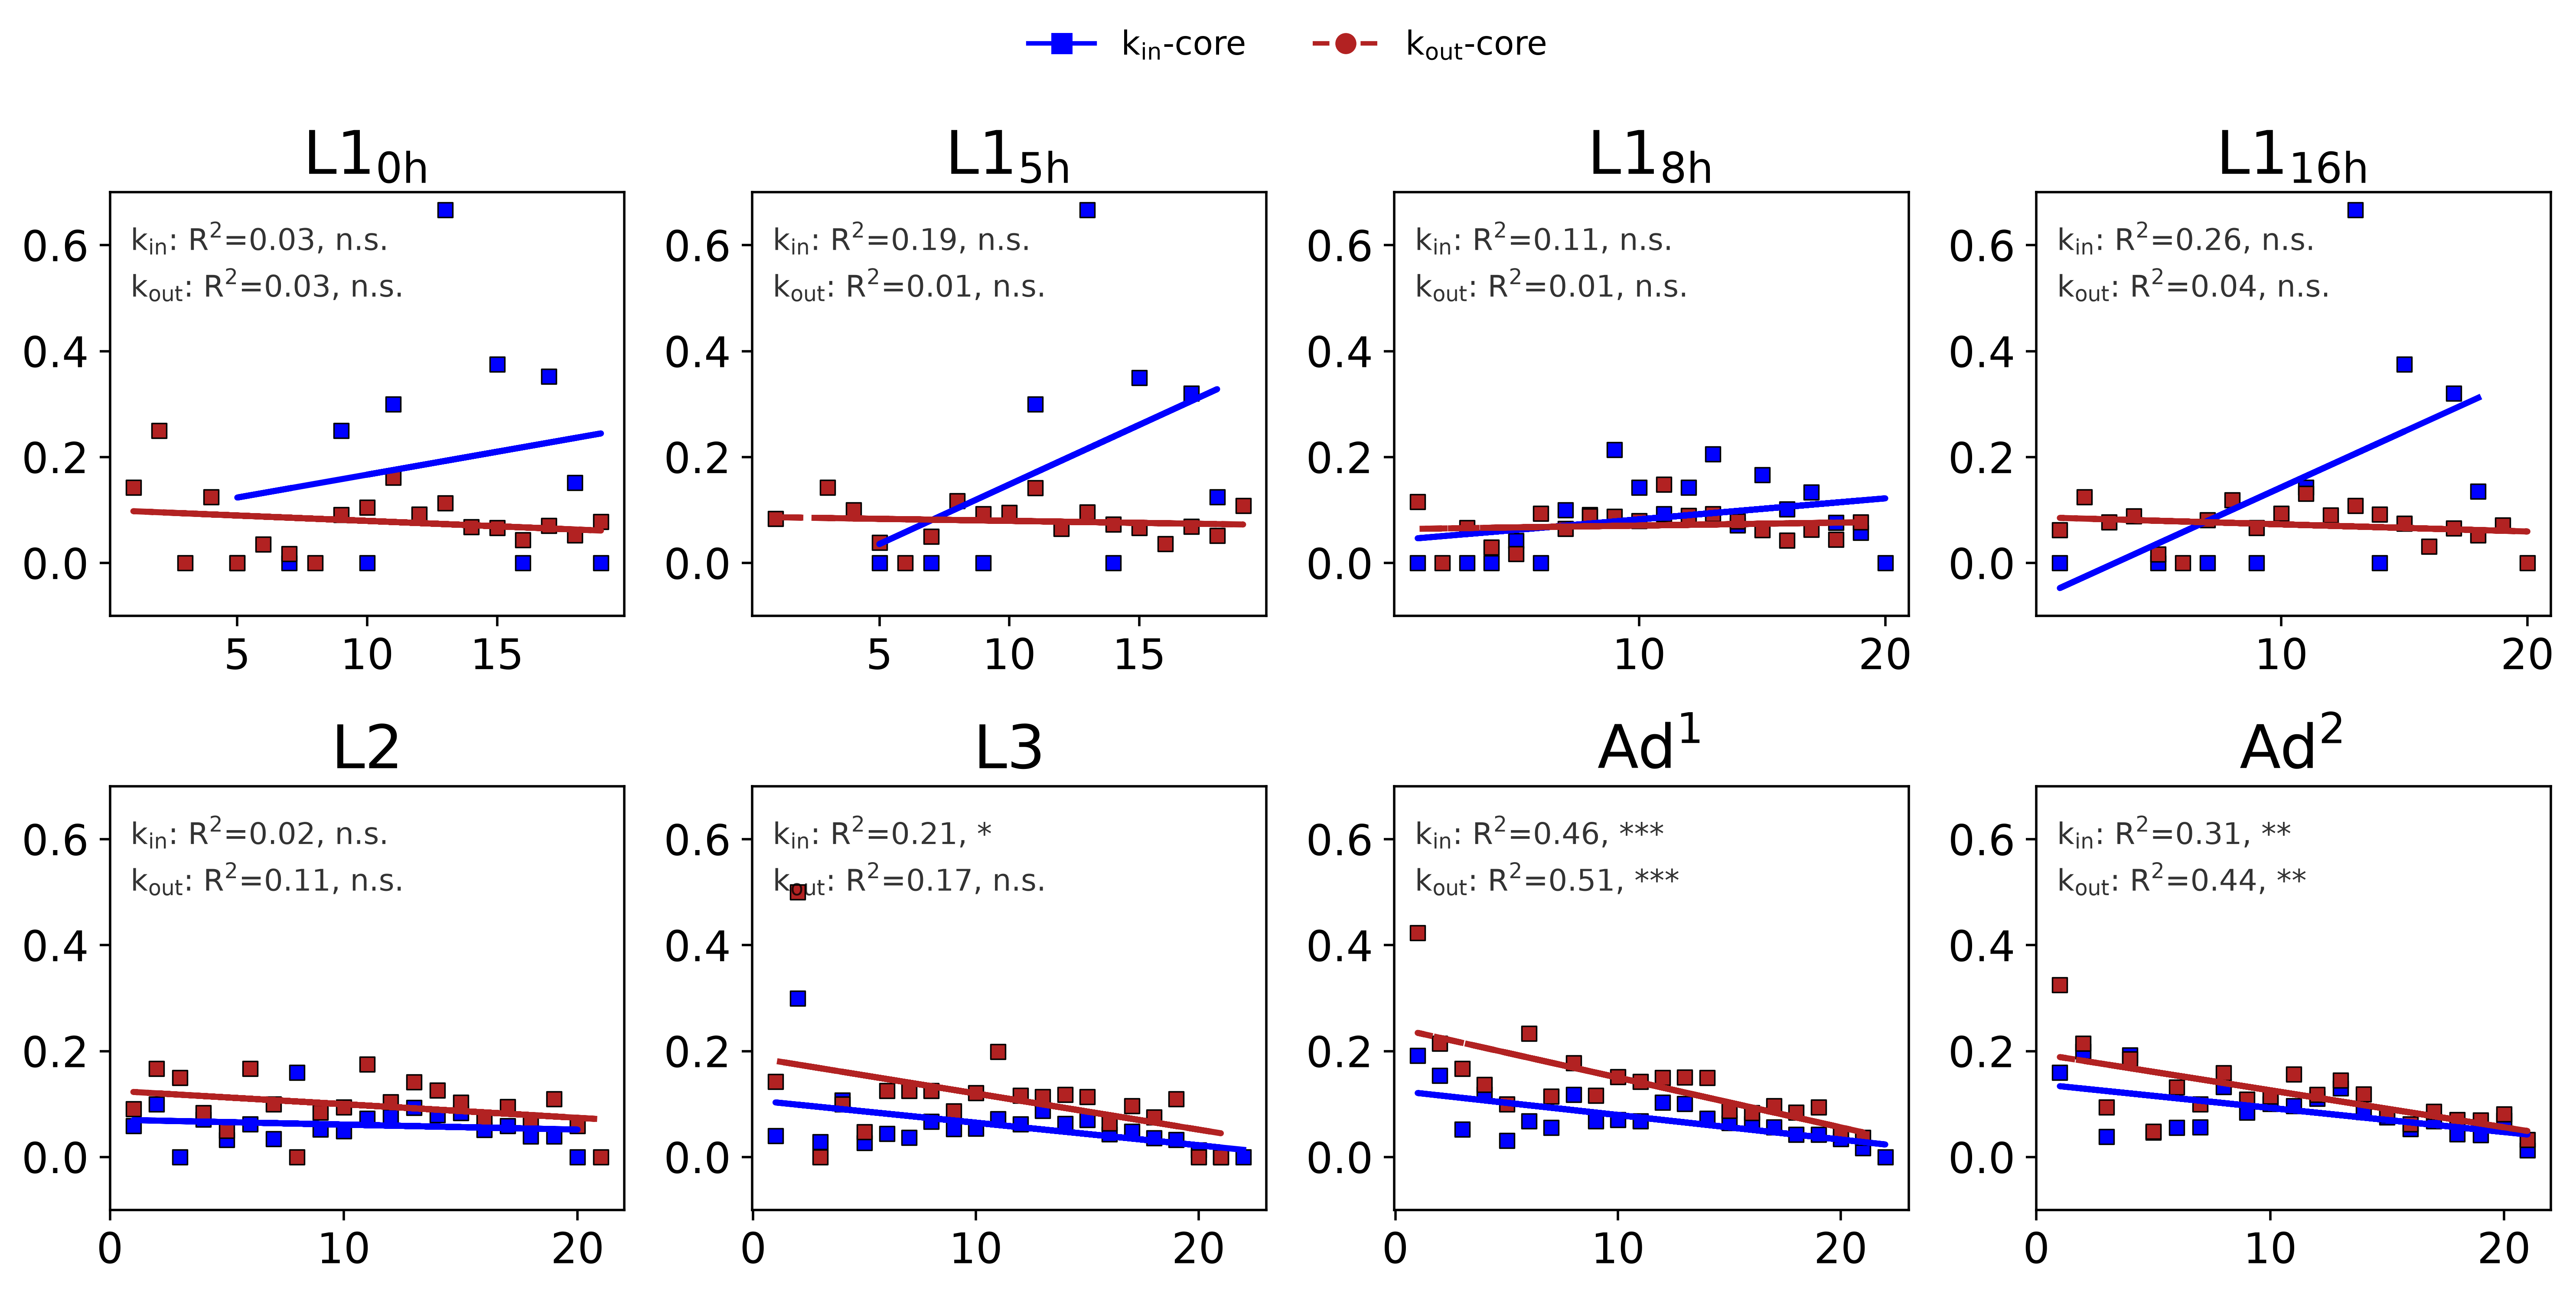

In [9]:
from scipy.stats import linregress
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(12, 6), dpi=500)
axes = axes.flatten()

ymax = 0  # to enforce common y-limit

def p_to_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "n.s."


for i in range(len(stage_labels_plot)):
    ax = axes[i]

    # -------- k_in core --------
    kin_data = connection_probability_kin_core_all_stages[i]
    x_in = list(kin_data.keys())
    y_in = list(kin_data.values())

    slope_in, intercept_in, r_in, p_in, _ = linregress(x_in, y_in)
    y_fit_in = [slope_in * xi + intercept_in for xi in x_in]

    ax.scatter(
        x_in, y_in,
        marker='s', s=25, color='blue',
        edgecolors='black', linewidth=0.5
    )
    ax.plot(
        x_in, y_fit_in,
        color='blue', linewidth=2
    )

    r2_in = r_in**2
    ax.text(
        0.04, 0.93,
        rf"$k_{{in}}$: $R^2$={r2_in:.2f}, {p_to_stars(p_in)}",
        transform=ax.transAxes,
        fontsize=10, va='top', alpha=0.8
    )


    # -------- k_out core --------
    kout_data = connection_probability_kout_core_all_stages[i]
    x_out = list(kout_data.keys())
    y_out = list(kout_data.values())

    slope_out, intercept_out, r_out, p_out, _ = linregress(x_out, y_out)
    y_fit_out = [slope_out * xi + intercept_out for xi in x_out]

    ax.scatter(
        x_out, y_out,
        marker='s', s=25, color='firebrick',
        edgecolors='black', linewidth=0.5
    )
    ax.plot(
        x_out, y_fit_out,
        linestyle='--', color='firebrick', linewidth=2
    )

    r2_out = r_out**2
    ax.text(
        0.04, 0.82,
        rf"$k_{{out}}$: $R^2$={r2_out:.2f}, {p_to_stars(p_out)}",
        transform=ax.transAxes,
        fontsize=10, va='top', alpha=0.8
    )


    # -------- axes & styling --------
    ax.set_title(stage_labels_plot[i], fontsize=20)
    #ax.set_xlabel("Lineage Distance", fontsize=11)
    #ax.set_ylabel("Connection Probability", fontsize=11)

    ax.tick_params(labelsize=14)

    ymax = max(ymax, max(y_in), max(y_out))

# -------- enforce common y-scale --------
for ax in axes:
    ax.set_ylim(-0.1, ymax * 1.05)

# -------- global legend --------
handles = [
    plt.Line2D([], [], marker='s', color='blue', linestyle='-', label=r"$k_{in}$-core"),
    plt.Line2D([], [], marker='o', color='firebrick', linestyle='--', label=r"$k_{out}$-core"),
]

fig.legend(
    handles=handles,
    loc='upper center',
    ncol=2,
    frameon=False,
    fontsize=11
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


**Lineage Distance wise connection probability of entire graph**

In [10]:
connection_probability_all_stages = {}
for i, graph in enumerate(all_c_elegans_weighted_graphs):
    nodes = graph.nodes()
    pair_count_per_distance = {}
    connected_pair_count_per_distance = {}

    for source, target in permutations(nodes, 2):  
        spclass_src, spclass_target = graph.nodes[source]['specific_class'], graph.nodes[target]['specific_class']
        
        distance = cell_lineages_distances_of_witvliet_data[(spclass_src, spclass_target)]
        pair_count_per_distance[distance] = pair_count_per_distance.get(distance, 0) + 1
        
        if graph.has_edge(source, target):
            connected_pair_count_per_distance[distance] = connected_pair_count_per_distance.get(distance, 0) + 1
            
        connection_probability = {
            dist: connected_pair_count_per_distance.get(dist, 0) / pair_count_per_distance[dist]
            for dist in pair_count_per_distance
        }
    connection_probability_all_stages[i] = connection_probability

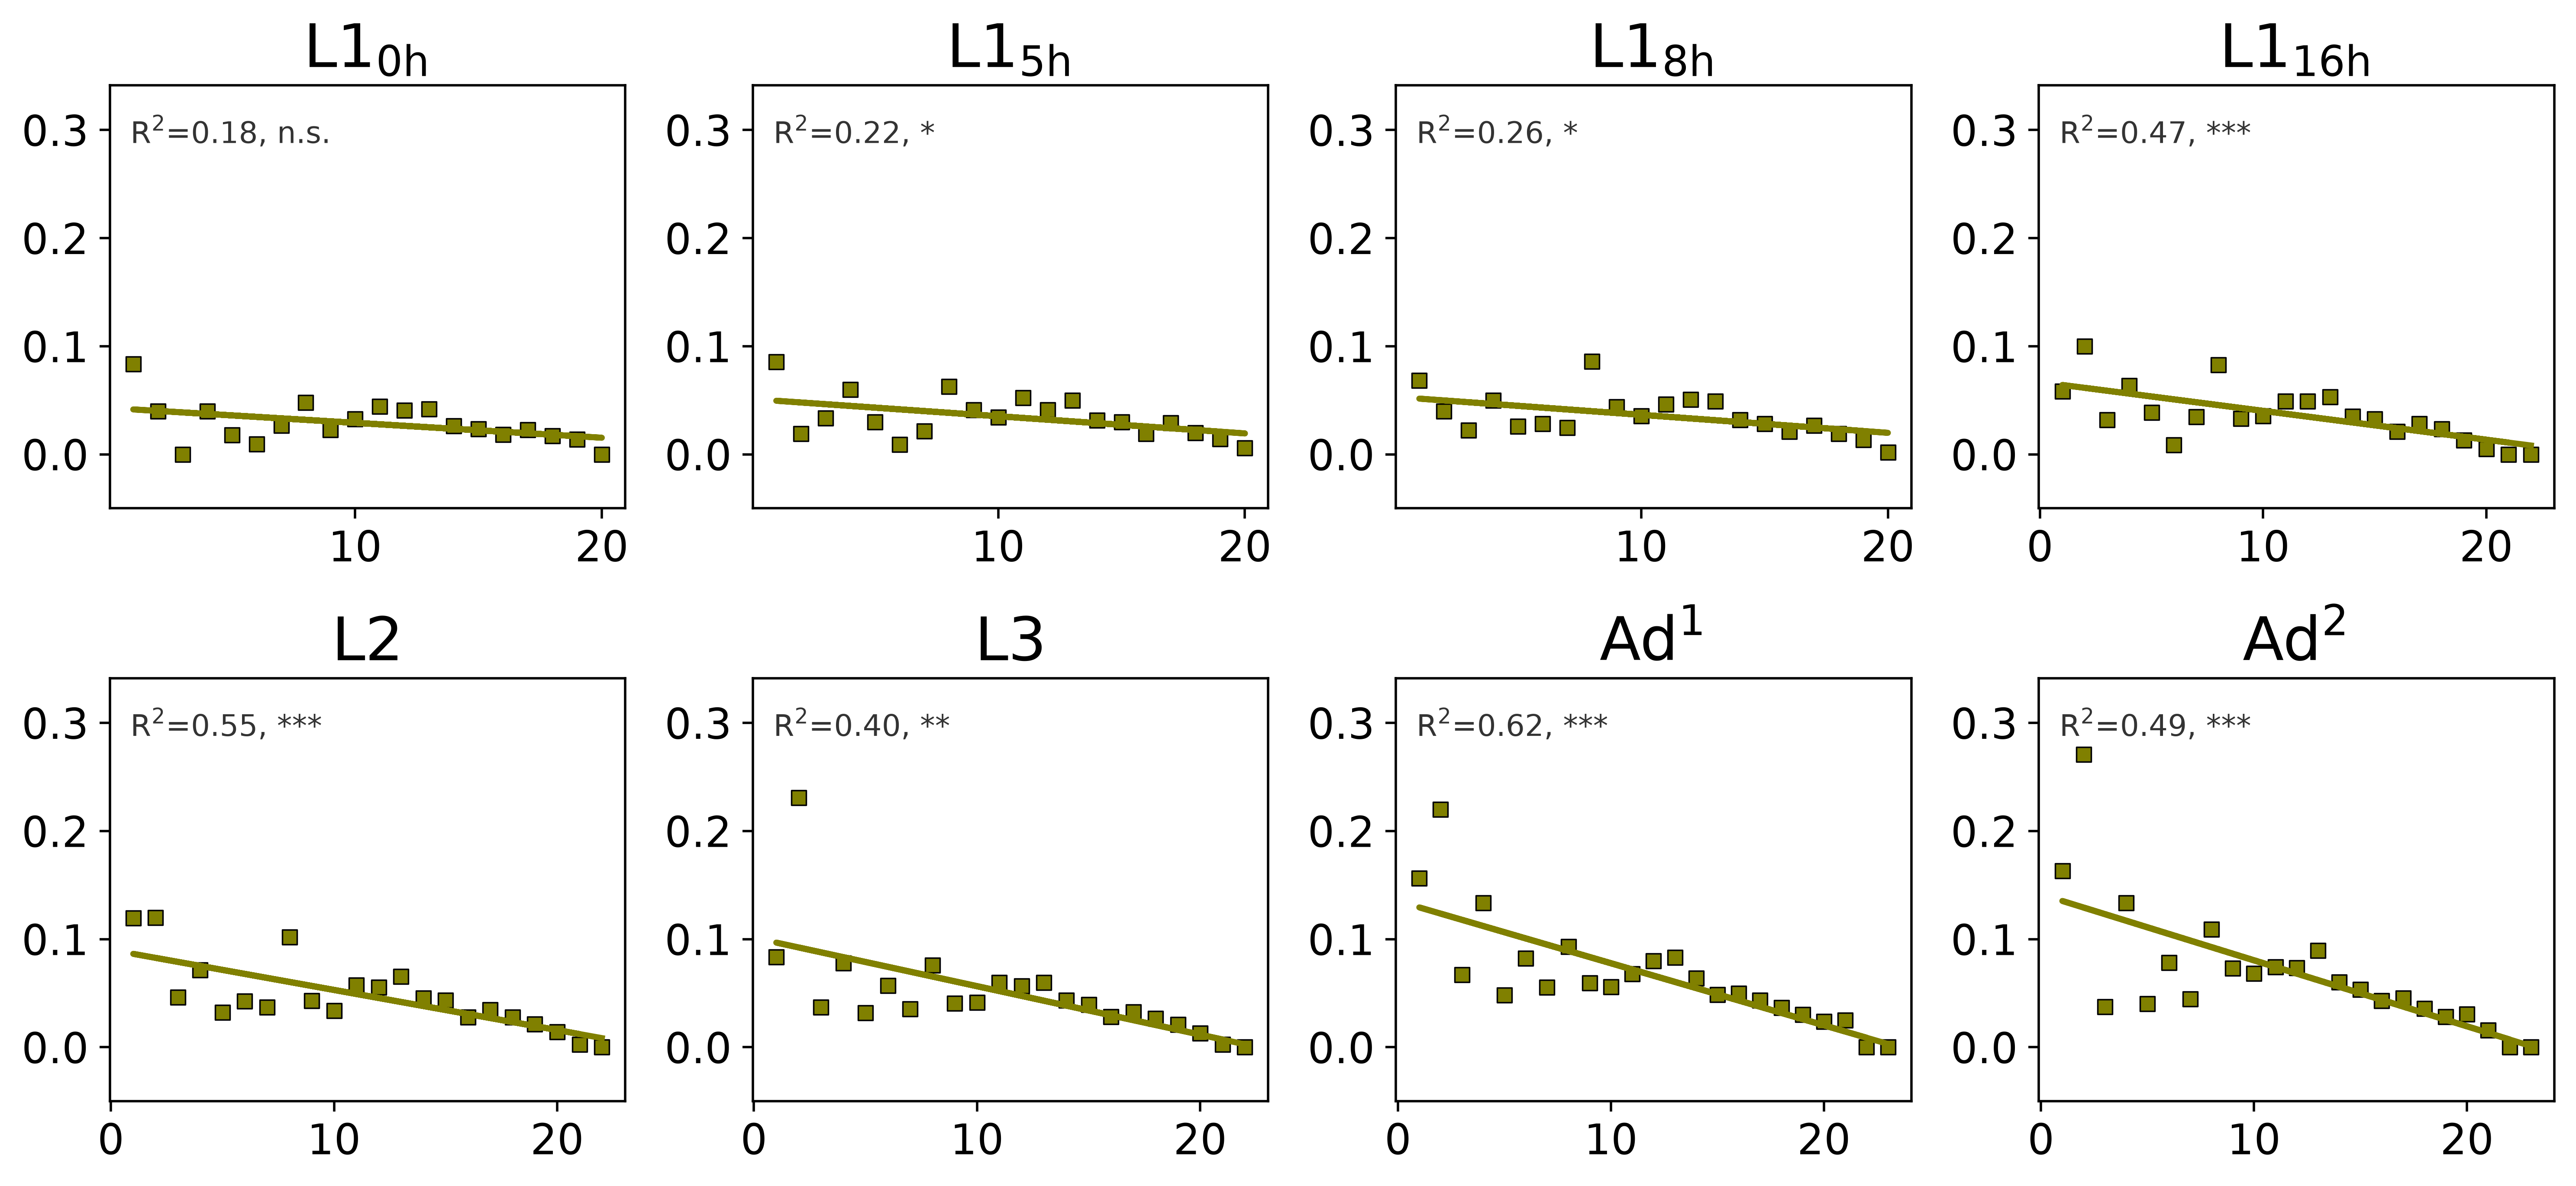

In [11]:
from scipy.stats import linregress
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(12, 6), dpi=500)
axes = axes.flatten()

ymax = 0  # to enforce common y-limit

def p_to_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "n.s."


for i in range(len(stage_labels_plot)):
    ax = axes[i]

    data = connection_probability_all_stages[i]
    x = list(data.keys())
    y = list(data.values())

    slope, intercept, r, p, _ = linregress(x, y)
    y_fit = [slope * xi + intercept for xi in x]

    ax.scatter(
        x, y,
        marker='s', s=25, color='olive',
        edgecolor='black', linewidth=0.5
    )
    ax.plot(
        x, y_fit,
        color='olive', linewidth=2
    )

    r2 = r**2
    ax.text(
        0.04, 0.93,
        rf"$R^2$={r2:.2f}, {p_to_stars(p)}",
        transform=ax.transAxes,
        fontsize=10, va='top', alpha=0.8
    )

    # -------- axes & styling --------
    ax.set_title(stage_labels_plot[i], fontsize=20)
    #ax.set_xlabel("Lineage Distance", fontsize=11)
    #ax.set_ylabel("Connection Probability", fontsize=11)

    ax.tick_params(labelsize=14)

    ymax = max(ymax, max(y), max(y_out))

# -------- enforce common y-scale --------
for ax in axes:
    ax.set_ylim(-0.05, ymax * 1.05)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()
